# MNIST DATASET with tensorflow

In [1]:
import tensorflow as tf

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
type(x_train)

numpy.ndarray

In [5]:
x_train.imag.shape

(60000, 28, 28)

In [10]:
# Normalizamos a 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encoding de las etiquetas
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

¿Por qué normalizar a [0,1]?

Numerical stability: las redes neuronales entrenan mejor si los valores de entrada son pequeños y uniformes.

Gradientes más estables: si los números son muy grandes (0–255), los gradientes pueden explotar o saturarse.

Convención: la mayoría de modelos espera entradas en el rango [0,1] o [-1,1].

One-hot encoding de las Y (etiquetas)

Las etiquetas en MNIST vienen como un número entero de 0 a 9 (el dígito que representa la imagen).

¿Por qué convertir a one-hot?

Muchas redes (especialmente las que terminan en Dense(10, activation="softmax")) esperan que la etiqueta tenga la misma dimensión que la salida de la red.

Si la red devuelve un vector de 10 probabilidades (una por clase), necesitamos que la etiqueta sea un vector de 10 elementos también.

7 → [0,0,0,0,0,0,0,1,0,0]


In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
x_train.imag[0].shape

(28, 28)

que pasa y por que el data saet ya me los da arreglado en 28x28, esto port que cargue el mismo desde el ejemplo y este lo da asi, de lo contrario esto daria un array que deberia de poner 28x28

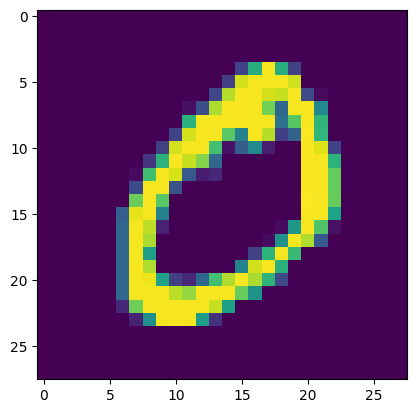

In [17]:
plt.imshow(x_train[1])

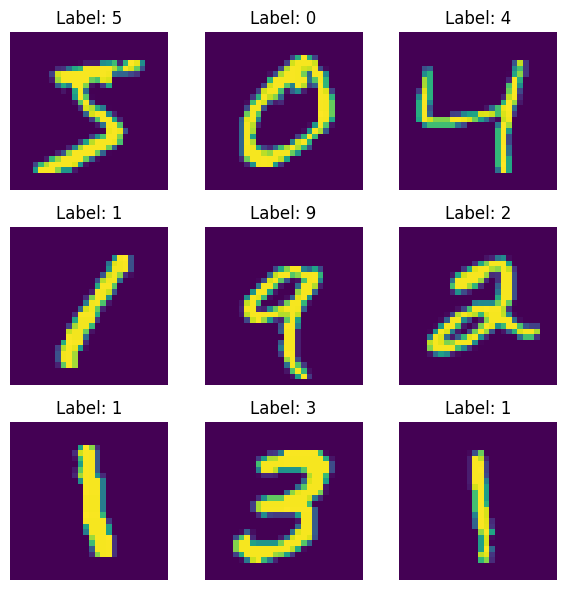

In [20]:
# para entonces hacer un subplot y poder ver varias imagenes

fig, axes = plt.subplots(3,3, figsize=(6,6))

for i , ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(f'Label: {y_train[i].argmax()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

como se comporta flat y por que lo utilizamos; .flat es un iterador que recorre todos los elementos de un array multidimensional como si fuera 1D.

axes es un array 2D de subplots (3x3).

.flat permite recorrer todos los subplots en orden sin tener que anidar dos loops (for row in axes: for ax in row:).

Hace el código más limpio y simple.

In [21]:
import numpy as np
a = np.array([[1, 2], [3, 4]])


In [22]:
a

array([[1, 2],
       [3, 4]])

In [23]:
for x in a.flat:
    print(x)

1
2
3
4


In [24]:
#como se comporta argmax()

a = np.array([0, 2, 5, 1])
print(a.argmax())

2


El valor máximo es 5, y su índice es 2.
y_train[i] es un vector one-hot de longitud 10, por ejemplo:
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]  # representa el dígito 3
.argmax() devuelve el índice donde está el 1 → 3

Así obtenemos el número real representado por esa etiqueta one-hot, para mostrarlo como título de la imagen.

#### Parte 2 

dado que tenemos la data ya dividida ahora toca inicializar la W = de pesos y la b = bias (sesgo
)

In [25]:
n_inputs = 28*28
n_outputs = 10

# Pesos: se suelen inicializar pequeños, normalmente con valores aleatorios
W = tf.Variable(tf.random.normal([n_inputs, n_outputs], stddev=0.1))
b = tf.Variable(tf.zeros([n_outputs]))

Cuando construimos un perceptrón simple o una capa densa, necesitamos que cada entrada sea un vector 1D.

Las redes neuronales no trabajan con matrices de 2D directamente (en perceptrones simples, sí en CNN se mantiene la estructura 2D).

Por eso “aplanamos” cada imagen

28*28 = 784


In [28]:
# x_train.reshape(-1, 784) aplana las imágenes de 28x28 a un vector de 784
logits = tf.matmul(x_train[:1].reshape(-1, 784), W) + b  # salida antes de softmax
y_pred = tf.nn.softmax(logits)  # convierte a probabilidades


In [32]:
# --- 1. Cargar MNIST ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Aplanar imágenes
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

n_inputs = 28*28
n_outputs = 10

# --- 2. Inicializar pesos y sesgo ---
W = tf.Variable(tf.random.normal([n_inputs, n_outputs], stddev=0.1))
b = tf.Variable(tf.zeros([n_outputs]))

# --- 3. Definir optimizador ---
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

# --- 4. Función de pérdida ---
loss_fn = tf.keras.losses.CategoricalCrossentropy()

In [33]:
# --- 5. Bucle de entrenamiento simple ---
epochs = 5
batch_size = 128
num_batches = x_train.shape[0] // batch_size

for epoch in range(epochs):
    # Mezclar los datos cada epoch
    idx = np.random.permutation(x_train.shape[0])
    x_train_shuffled = x_train[idx]
    y_train_shuffled = y_train[idx]

    epoch_loss = 0
    for i in range(num_batches):
        x_batch = x_train_shuffled[i*batch_size:(i+1)*batch_size]
        y_batch = y_train_shuffled[i*batch_size:(i+1)*batch_size]

        # GradientTape para backpropagation automática
        with tf.GradientTape() as tape:
            logits = tf.matmul(x_batch, W) + b
            y_pred = tf.nn.softmax(logits)
            loss = loss_fn(y_batch, y_pred)

        # Calcular gradientes
        gradients = tape.gradient(loss, [W, b])
        # Actualizar parámetros
        optimizer.apply_gradients(zip(gradients, [W, b]))

        epoch_loss += loss.numpy()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/num_batches:.4f}")

Epoch 1/5, Loss: 0.6096
Epoch 2/5, Loss: 0.3821
Epoch 3/5, Loss: 0.3481
Epoch 4/5, Loss: 0.3300
Epoch 5/5, Loss: 0.3194


In [34]:
# --- 6. Evaluar en test set ---
logits_test = tf.matmul(x_test, W) + b
y_pred_test = tf.nn.softmax(logits_test)
accuracy = np.mean(np.argmax(y_pred_test.numpy(), axis=1) == np.argmax(y_test, axis=1))
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9164
